# Build matrix of interactions

In [52]:
import os
import pandas as pd
from plip.structure.preparation import PDBComplex

# Protein names (longest first to avoid partial matches)
proteins = [
    #"PDE4B_monomer_md",
    #"PDE4B_dimer",
    "PDE4D_catalytic",
]

interaction_types = [
    "hydrophobic_contacts",
    "hbonds_ldon",
    "hbonds_pdon",
    "water_bridges",
    "saltbridge_lneg",
    "saltbridge_pneg",
    "pistacking",
    "pication_laro",
    "pication_paro",
    "halogen_bonds",
    "metal_complexes",
]

rows = []

pdb_folder = "../pdbs"

for pdb_file in sorted(os.listdir(pdb_folder)):
    print(pdb_file)
    if not pdb_file.endswith(".pdb"):
        continue

    basename = os.path.splitext(pdb_file)[0]

    # Identify protein and ligand from filename
    protein = None
    ligand = None
    for p in proteins:
        if basename.startswith(p + "_"):
            protein = p
            ligand = basename[len(p) + 1:]
            break

    if protein is None:
        print(f"Skipping {pdb_file}: protein not recognized.")
        continue

    pdb_path = os.path.join(pdb_folder, pdb_file)

    mol = PDBComplex()
    mol.load_pdb(pdb_path)
    mol.analyze()

    for bsid, inter in mol.interaction_sets.items():

        # # Ignore cofactors/ions (keep only the docked ligand)
        # if inter.ligand.hetid != "UNL":
        #     continue

        for interaction_type in interaction_types:

            if not hasattr(inter, interaction_type):
                continue

            interactions = getattr(inter, interaction_type)

            for i in interactions:

                rows.append({
                    "protein": protein,
                    "ligand": ligand,
                    "binding_site": bsid,
                    "interaction_type": interaction_type,
                    "residue_number": getattr(i, "resnr", None),
                    "residue_name": getattr(i, "restype", None),
                    "residue_chain": getattr(i, "reschain", None),
                })


ModuleNotFoundError: No module named 'plip'

In [ ]:
# convert the list of dict to df 
df = pd.DataFrame(rows)

# create res id column with name, position and chain
df["residue_id"] = (
    df["residue_name"].astype(str) +
    df["residue_number"].astype("Int64").astype(str) +
    ":" +
    df["residue_chain"].astype(str)
)

df.to_csv("protein_interactions.csv", index=False)


In [1]:
import pandas as pd

df = pd.read_csv('protein_interactions.csv')
#df = pd.read_csv('/home/gbiuser/Documents/vitoria/usp-masters/8-docking/interactions/protein_interactions.csv')    
print(df.shape)
print(df.columns)

(3663, 8)
Index(['protein', 'ligand', 'binding_site', 'interaction_type',
       'residue_number', 'residue_name', 'residue_chain', 'residue_id'],
      dtype='object')


In [2]:
df["protein"].value_counts()

protein
PDE4D_dimer        860
PDE4D_catalytic    851
PDE4B_monomer      717
PDE4B_catalytic    692
PDE4B_dimer        656
PDE4D_monomer      585
Name: count, dtype: int64

## Conserved residues across all complexes

In [2]:
# create df disconsindering ions
df_lig = df[df["binding_site"].str.startswith("UNL:")].copy()


In [5]:
# aggregate number of interactions based on number of proteins and ligands 
conserved = (
    df_lig.groupby("residue_id")
            .agg(
                n_proteins=("protein", "nunique"),
                n_ligands=("ligand", "nunique"),
                n_complexes=("protein", lambda x: len(set(zip(x, df.loc[x.index, "ligand"])))),
            )         
            .reset_index()
)

In [6]:
conserved.sort_values("n_complexes", ascending=False).head(20)

,residue_id,n_proteins,n_ligands,n_complexes
76,PHE453:A,3,20,53
80,PHE618:A,3,20,53
109,TYR405:A,3,20,44
52,ILE582:A,3,20,42
49,ILE417:A,3,20,42
74,PHE421:A,3,19,33
79,PHE586:A,3,19,33
75,PHE452:A,2,18,32
7,ASN567:A,3,15,30
48,ILE416:A,2,18,29


In [8]:
conserved.sort_values("n_proteins", ascending=False).head(20)

,residue_id,n_proteins,n_ligands,n_complexes
50,ILE582:A,3,20,30
23,GLN615:A,3,17,29
20,GLN450:A,3,16,23
47,ILE417:A,3,20,29
89,SER614:A,3,5,6
9,ASN567:A,2,15,19
18,GLN423:A,2,2,2
15,ASP564:A,2,16,20
46,ILE416:A,2,18,29
39,HIS406:A,2,12,18


### Conserved only in PDE4B

In [ ]:
PDE4B_subset = [
    "PDE4B_dimer",
    "PDE4B_monomer",
    "PDE4B_catalytic"
]

df_subset = df_lig[
    df_lig["protein"].isin(PDE4B_subset)
].copy()

conserved_PDE4B = (
    df_subset.groupby("residue_id")
             .agg(
                 n_proteins=("protein", "nunique"),
                 n_ligands=("ligand", "nunique"),
                 n_complexes=("protein", lambda x: len(set(zip(x, df_subset.loc[x.index, "ligand"]))))
             )
             .reset_index()
             .sort_values(
                 ["n_proteins", "n_ligands"],
                 ascending=False
             )
)



   residue_id  n_proteins  n_ligands  n_complexes
13   ILE582:A           3         20           42
19   PHE618:A           3         20           53
26   TYR405:A           3         20           46
18   PHE586:A           3         19           33
9    HIS406:A           3         18           34
6    GLN615:A           3         17           28
1    ASN567:A           3         16           34
4    ASP564:A           3         16           23
16   MET519:A           3         10           13
12   HIS450:A           3          9           10
15   LEU565:A           3          7           13
17   MET603:A           3          6            7
7    GLU476:A           3          3            4
20   SER454:A           2         12           13
10   HIS410:A           2          6           10
8    GLU585:A           2          5            5
11   HIS446:A           2          5            5
23   SER614:A           2          5            5
0    ASN455:A           2          4            6


In [4]:
conserved_PDE4B.head(30)

,residue_id,n_proteins,n_ligands,n_complexes
13,ILE582:A,3,20,42
19,PHE618:A,3,20,53
26,TYR405:A,3,20,46
18,PHE586:A,3,19,33
9,HIS406:A,3,18,34
6,GLN615:A,3,17,28
1,ASN567:A,3,16,34
4,ASP564:A,3,16,23
16,MET519:A,3,10,13
12,HIS450:A,3,9,10


check pde4b other chain

In [14]:
df_lig[(df_lig["protein"] == "PDE4B_dimer") & (df_lig["residue_chain"] == "B")]

,protein,ligand,binding_site,interaction_type,residue_number,residue_name,residue_chain,residue_id


In [15]:
df_lig[(df_lig["protein"] == "PDE4D_dimer") & (df_lig["residue_chain"] == "B")]

,protein,ligand,binding_site,interaction_type,residue_number,residue_name,residue_chain,residue_id


## Interaction fingerprint (IFP) analysis

In [15]:
fp_ligand = (
    df_lig.assign(value=1)
          .pivot_table(
              index="ligand",
              columns="residue_id",
              values="value",
              aggfunc="max",
              fill_value=0
          )
)


In [16]:
known = ["rolR", "rf", "rolS"]

known_fp = fp_ligand.loc[known]

shared = known_fp.sum(axis=0) == len(known)


### Clustering

In [17]:
fp = (
    df_lig.assign(value=1)
           .pivot_table(
               index=["protein", "ligand"],
               columns="residue_id",
               values="value",
               aggfunc="max",
               fill_value=0
           )
)

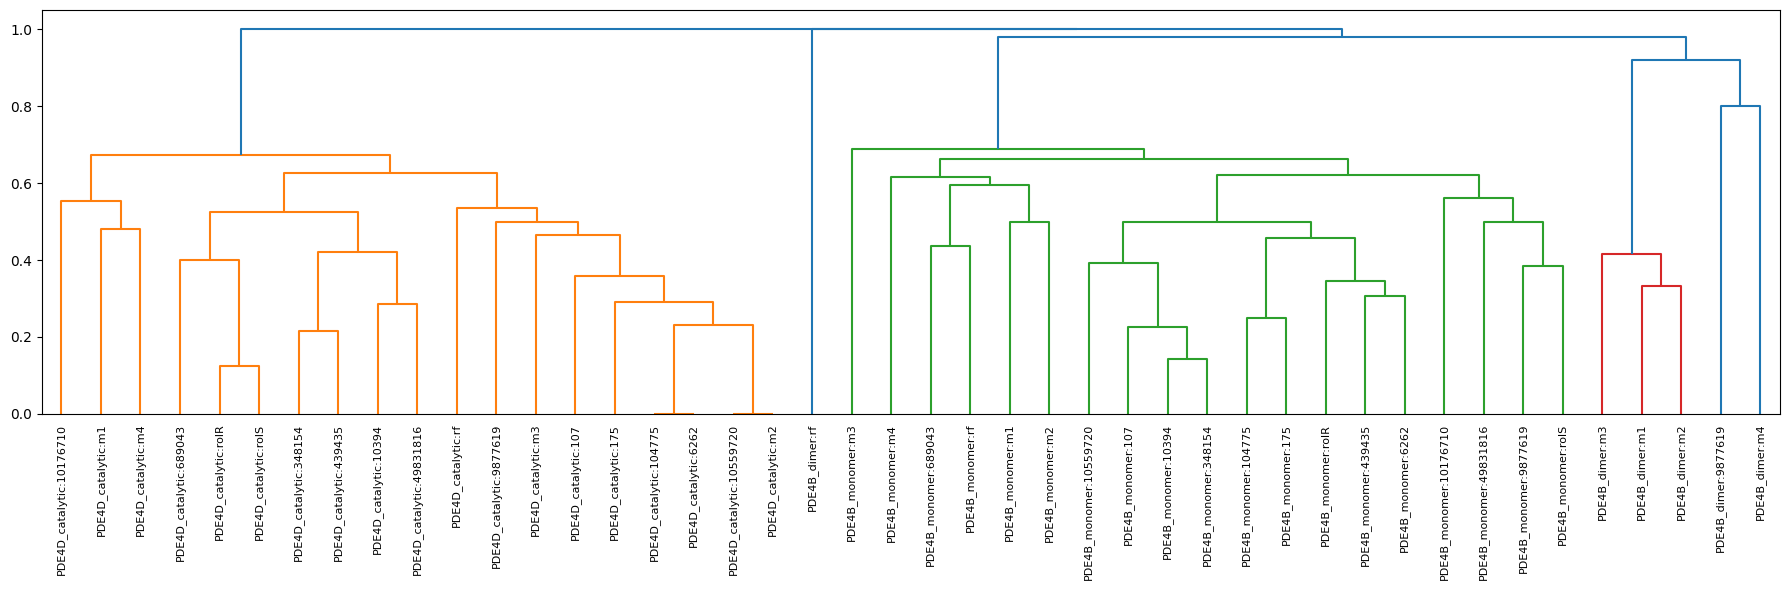

In [18]:
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram

distance = pdist(fp.values, metric="jaccard")

Z = linkage(distance, method="average")

plt.figure(figsize=(18,6))

dendrogram(
    Z,
    labels=[f"{p}:{l}" for p, l in fp.index],
    leaf_rotation=90
)

plt.tight_layout()
plt.show()

# types analysis

In [9]:
df_lig.columns

Index(['protein', 'ligand', 'binding_site', 'interaction_type',
       'residue_number', 'residue_name', 'residue_chain', 'residue_id'],
      dtype='object')

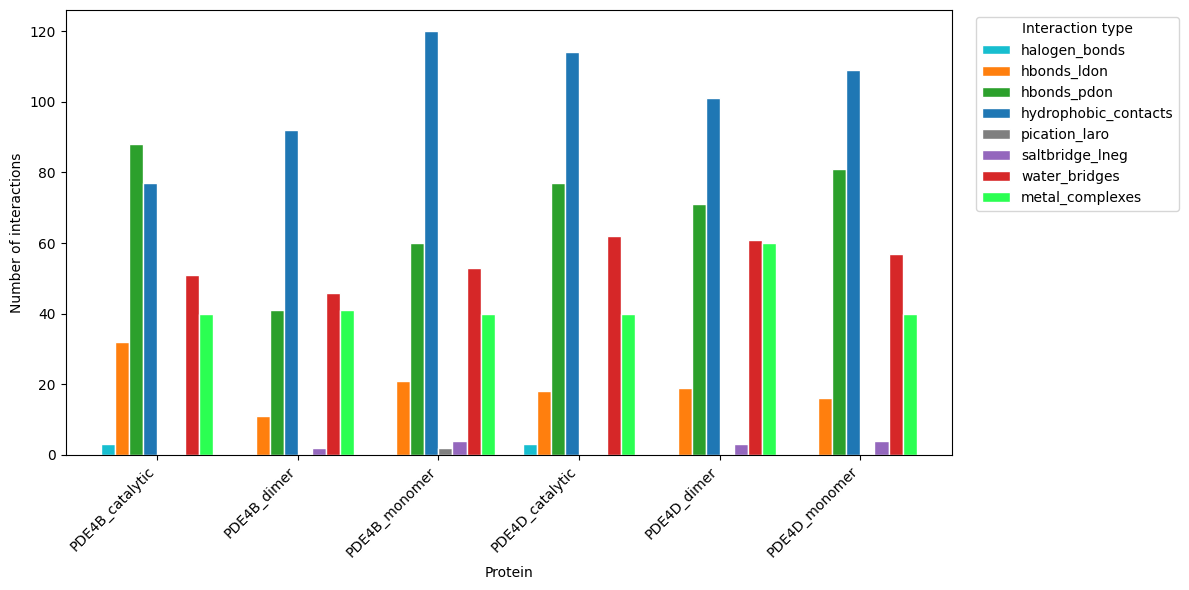

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

colors = {
    "hydrophobic_contacts": "#1f77b4",
    "hbonds_ldon": "#ff7f0e",
    "hbonds_pdon": "#2ca02c",
    "water_bridges": "#d62728",
    "saltbridge_lneg": "#9467bd",
    "saltbridge_pneg": "#8c564b",
    "pistacking": "#e377c2",
    "pication_laro": "#7f7f7f",
    "pication_paro": "#bcbd22",
    "halogen_bonds": "#17becf",
    "metal_complexes": "#2bff52",}

counts = (
    df[df["interaction_type"] != "metal_complexes"]
    .groupby(["protein", "interaction_type"])
    .size()
    .unstack(fill_value=0))

# Count unique ligand-metal complexes
metal_counts = (
    df[df["interaction_type"] == "metal_complexes"]
    [["protein", "ligand", "binding_site"]]
    .drop_duplicates()
    .groupby("protein")
    .size()
)

counts["metal_complexes"] = metal_counts
counts = counts.fillna(0)

ax = counts.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8,
    color=[colors.get(i, "#333333") for i in counts.columns],
    edgecolor="white",
    linewidth=1
)

ax.set_xlabel("Protein")
ax.set_ylabel("Number of interactions")
ax.legend(title="Interaction type", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [43]:
counts

interaction_type,halogen_bonds,hbonds_ldon,hbonds_pdon,hydrophobic_contacts,pication_laro,saltbridge_lneg,water_bridges,metal_complexes
protein,,,,,,,,
PDE4B_catalytic,3,32,88,77,0,0,51,40
PDE4B_dimer,0,11,41,92,0,2,46,41
PDE4B_monomer,0,21,60,120,2,4,53,40
PDE4D_catalytic,3,18,77,114,0,0,62,40
PDE4D_dimer,0,19,71,101,0,3,61,60
PDE4D_monomer,0,16,81,109,0,4,57,40


In [44]:
pd.set_option("display.max_columns", None)

df[
    (df["protein"] == "PDE4D_dimer") &
    (df["interaction_type"] == "metal_complexes") &
    (df["binding_site"].str.startswith("ZN:", na=False))

][[
    #"ligand",
    "binding_site",
    #"residue_number",
    #"residue_name",
    #"residue_chain",
    #"residue_id"
]].value_counts()

binding_site
ZN:A:1223       200
ZN:B:1223       200
Name: count, dtype: int64

In [45]:
pd.set_option("display.max_columns", None)

df[
    (df["protein"] == "PDE4B_dimer") &
    (df["interaction_type"] == "metal_complexes") &
    (df["binding_site"].str.startswith("ZN:", na=False))

][[
    #"ligand",
    "binding_site",
    #"residue_number",
    #"residue_name",
    #"residue_chain",
    #"residue_id"
]].value_counts()

binding_site
ZN:A:801        160
ZN:B:801        160
Name: count, dtype: int64

In [41]:
df[
    (df["protein"].isin(["PDE4B_dimer", "PDE4D_dimer"])) &
    (df["interaction_type"] == "metal_complexes")
][["protein", "ligand", "binding_site"]].value_counts(
    ["protein", "binding_site"]
)

protein      binding_site
PDE4D_dimer  ZN:A:1223       200
             MG:B:1224       200
             ZN:B:1223       200
PDE4B_dimer  ZN:A:801        160
             ZN:B:801        160
             MG:A:804          2
Name: count, dtype: int64

In [47]:
pd.set_option("display.max_columns", None)

df[
    (df["protein"] == "PDE4B_dimer") &
    (df["residue_chain"] == "B") 
    #(df["binding_site"].str.startswith("ZN:", na=False))

][[
    "ligand",
    "binding_site",
    "residue_number",
    "residue_name",
    "residue_chain",
    "residue_id"
]].value_counts()

ligand    binding_site  residue_number  residue_name  residue_chain  residue_id
10176710  ZN:B:801      446             HIS           B              HIS446:B      8
10394     ZN:B:801      446             HIS           B              HIS446:B      8
104775    ZN:B:801      446             HIS           B              HIS446:B      8
10559720  ZN:B:801      446             HIS           B              HIS446:B      8
107       ZN:B:801      446             HIS           B              HIS446:B      8
175       ZN:B:801      446             HIS           B              HIS446:B      8
348154    ZN:B:801      446             HIS           B              HIS446:B      8
439435    ZN:B:801      446             HIS           B              HIS446:B      8
49831816  ZN:B:801      446             HIS           B              HIS446:B      8
6262      ZN:B:801      446             HIS           B              HIS446:B      8
689043    ZN:B:801      446             HIS           B              H

In [50]:
df[
    (df["protein"] == "PDE4B_dimer") &
    (df["binding_site"] == "ZN:B:801") &
    (df["ligand"] == "m1")
]

,protein,ligand,binding_site,interaction_type,residue_number,residue_name,residue_chain,residue_id
849,PDE4B_dimer,m1,ZN:B:801,metal_complexes,446,HIS,B,HIS446:B
850,PDE4B_dimer,m1,ZN:B:801,metal_complexes,446,HIS,B,HIS446:B
851,PDE4B_dimer,m1,ZN:B:801,metal_complexes,446,HIS,B,HIS446:B
852,PDE4B_dimer,m1,ZN:B:801,metal_complexes,446,HIS,B,HIS446:B
853,PDE4B_dimer,m1,ZN:B:801,metal_complexes,446,HIS,B,HIS446:B
854,PDE4B_dimer,m1,ZN:B:801,metal_complexes,446,HIS,B,HIS446:B
855,PDE4B_dimer,m1,ZN:B:801,metal_complexes,446,HIS,B,HIS446:B
856,PDE4B_dimer,m1,ZN:B:801,metal_complexes,446,HIS,B,HIS446:B


In [49]:
pd.set_option("display.max_rows", None)

df[
    (df["protein"] == "PDE4D_dimer") &
    (df["residue_chain"] == "B") 
    #(df["binding_site"].str.startswith("ZN:", na=False))

][[
    "ligand",
    "binding_site",
    "residue_number",
    "residue_name",
    "residue_chain",
    "residue_id"
]].value_counts()

ligand    binding_site  residue_number  residue_name  residue_chain  residue_id
10176710  ZN:B:1223     502             HIS           B              HIS502:B      8
10559720  ZN:B:1223     502             HIS           B              HIS502:B      8
104775    ZN:B:1223     502             HIS           B              HIS502:B      8
10394     ZN:B:1223     502             HIS           B              HIS502:B      8
175       ZN:B:1223     502             HIS           B              HIS502:B      8
348154    ZN:B:1223     502             HIS           B              HIS502:B      8
107       ZN:B:1223     502             HIS           B              HIS502:B      8
m5        ZN:B:1223     502             HIS           B              HIS502:B      8
rolR      ZN:B:1223     502             HIS           B              HIS502:B      8
rolS      ZN:B:1223     502             HIS           B              HIS502:B      8
rf        ZN:B:1223     502             HIS           B              H

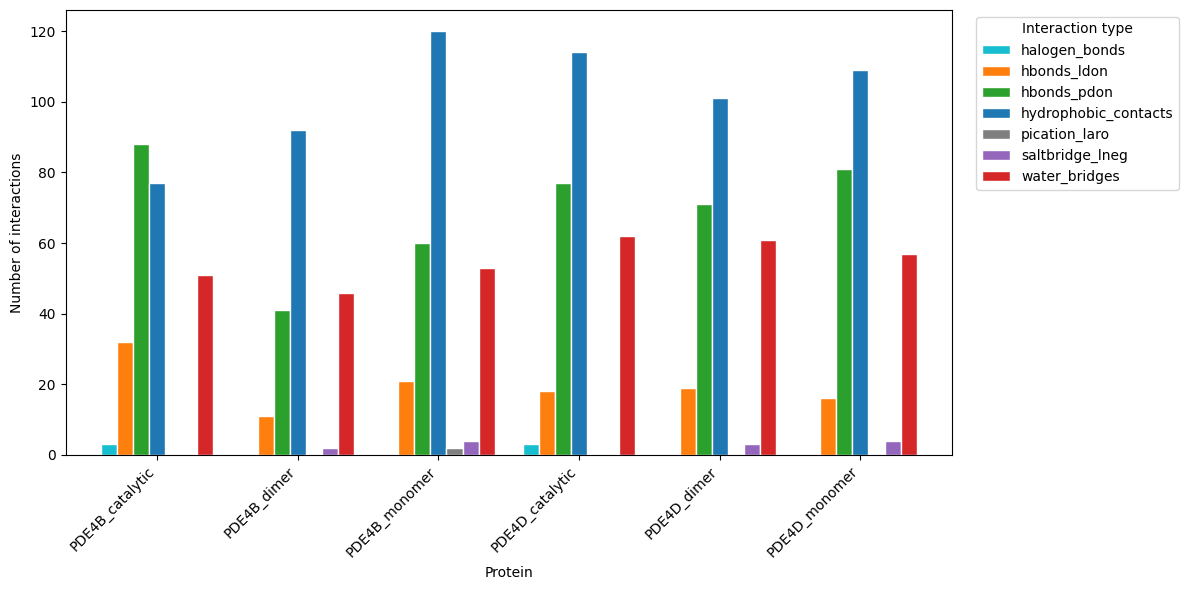

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

counts = (
    df_lig.groupby(["protein", "interaction_type"])
      .size()
      .unstack(fill_value=0)
)

ax = counts.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8,
    color=[colors.get(i, "#333333") for i in counts.columns],
    edgecolor="white",
    linewidth=1
)

ax.set_xlabel("Protein")
ax.set_ylabel("Number of interactions")
ax.legend(title="Interaction type", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [14]:
counts

interaction_type,halogen_bonds,hbonds_ldon,hbonds_pdon,hydrophobic_contacts,pication_laro,saltbridge_lneg,water_bridges
protein,,,,,,,
PDE4B_catalytic,3,32,86,151,0,0,98
PDE4B_dimer,0,11,43,180,0,4,96
PDE4B_monomer,0,21,52,238,4,8,114
PDE4D_catalytic,3,18,81,225,0,0,124
PDE4D_dimer,0,19,70,104,0,3,64
PDE4D_monomer,0,16,79,109,0,4,57


In [26]:
counts.to_csv("interaction_counts.tsv", sep="\t")

In [27]:
for protein, group in df.groupby("protein"):
    print(protein, group["ligand"].nunique(), group["ligand"].unique())

PDE4B_catalytic 20 ['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 'm5' 'rf' 'rolR'
 'rolS']
PDE4B_dimer 20 ['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 'm5' 'rf' 'rolR'
 'rolS']
PDE4B_monomer 20 ['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 'm5' 'rf' 'rolR'
 'rolS']
PDE4D_catalytic 20 ['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 'm5' 'rf' 'rolR'
 'rolS']
PDE4D_dimer 20 ['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 'm5' 'rf' 'rolR'
 'rolS']
PDE4D_monomer 20 ['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 

In [28]:
interaction_counts = (
    df.groupby(["protein", "ligand"])
      .size()
      .reset_index(name="n_interactions")
)

print(interaction_counts.to_string(index=False))

        protein   ligand  n_interactions
PDE4B_catalytic 10176710              42
PDE4B_catalytic    10394              36
PDE4B_catalytic   104775              23
PDE4B_catalytic 10559720              37
PDE4B_catalytic      107              33
PDE4B_catalytic      175              22
PDE4B_catalytic   348154              34
PDE4B_catalytic   439435              37
PDE4B_catalytic 49831816              40
PDE4B_catalytic     6262              26
PDE4B_catalytic   689043              35
PDE4B_catalytic  9877619              30
PDE4B_catalytic       m1              41
PDE4B_catalytic       m2              38
PDE4B_catalytic       m3              33
PDE4B_catalytic       m4              38
PDE4B_catalytic       m5              41
PDE4B_catalytic       rf              33
PDE4B_catalytic     rolR              39
PDE4B_catalytic     rolS              34
    PDE4B_dimer 10176710              48
    PDE4B_dimer    10394              48
    PDE4B_dimer   104775              48
    PDE4B_dimer 

In [29]:
for protein, group in df.groupby("protein"):
    print("\n", protein)
    print(group["ligand"].unique())


 PDE4B_catalytic
['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 'm5' 'rf' 'rolR'
 'rolS']

 PDE4B_dimer
['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 'm5' 'rf' 'rolR'
 'rolS']

 PDE4B_monomer
['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 'm5' 'rf' 'rolR'
 'rolS']

 PDE4D_catalytic
['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 'm5' 'rf' 'rolR'
 'rolS']

 PDE4D_dimer
['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 'm5' 'rf' 'rolR'
 'rolS']

 PDE4D_monomer
['10176710' '10394' '104775' '10559720' '107' '175' '348154' '439435'
 '49831816' '6262' '689043' '9877619' 'm1' 'm2' 'm3' 'm4' 'm5' '

In [30]:
from collections import Counter

pdb_file = "../pdbs/PDE4B_dimer_rolS.pdb"

atoms = []

with open(pdb_file) as f:
    for line in f:
        if line.startswith(("ATOM", "HETATM")):
            atom = line[12:16].strip()
            resname = line[17:20].strip()
            chain = line[21].strip()
            resid = line[22:26].strip()
            atoms.append((atom, resname, chain, resid))

print("Total atoms:", len(atoms))

Total atoms: 94461


In [31]:
from collections import Counter

counts = Counter(atoms)

duplicates = {k: v for k, v in counts.items() if v > 1}

print("Unique atom records:", len(counts))
print("Duplicated atom records:", len(duplicates))

for atom, n in list(duplicates.items())[:20]:
    print(n, atom)

Unique atom records: 33435
Duplicated atom records: 30198
3 ('N', 'VAL', 'A', '166')
3 ('CA', 'VAL', 'A', '166')
3 ('C', 'VAL', 'A', '166')
3 ('O', 'VAL', 'A', '166')
3 ('CB', 'VAL', 'A', '166')
3 ('CG1', 'VAL', 'A', '166')
3 ('CG2', 'VAL', 'A', '166')
3 ('HA', 'VAL', 'A', '166')
3 ('HB', 'VAL', 'A', '166')
3 ('1HG1', 'VAL', 'A', '166')
3 ('2HG1', 'VAL', 'A', '166')
3 ('3HG1', 'VAL', 'A', '166')
3 ('1HG2', 'VAL', 'A', '166')
3 ('2HG2', 'VAL', 'A', '166')
3 ('3HG2', 'VAL', 'A', '166')
2 ('HN2', 'VAL', 'A', '166')
2 ('HN1', 'VAL', 'A', '166')
2 ('HN3', 'VAL', 'A', '166')
2 ('HN4', 'VAL', 'A', '166')
6 ('N', 'THR', 'A', '167')


In [32]:
dimer = df[df["protein"] == "PDE4B_dimer"]

print(
    dimer.groupby(["ligand", "interaction_type"])
         .size()
         .unstack(fill_value=0)
         .to_string()
)

interaction_type  hbonds_ldon  hbonds_pdon  hydrophobic_contacts  metal_complexes  saltbridge_lneg  water_bridges
ligand                                                                                                           
10176710                    0            0                     0               48                0              0
10394                       0            0                     0               48                0              0
104775                      0            0                     0               48                0              0
10559720                    0            0                     0               48                0              0
107                         0            0                     0               48                0              0
175                         0            0                     0               48                0              0
348154                      0            0                     0               48       

In [33]:
print(
    dimer.groupby(["ligand", "residue_id"])
         .size()
         .sort_values(ascending=False)
         .head(30)
)

ligand    residue_id
10394     HIS446:B      16
10176710  HIS446:B      16
439435    HIS446:B      16
49831816  HIS446:B      16
6262      HIS446:B      16
348154    HIS446:B      16
107       HIS446:B      16
175       HIS446:B      16
10559720  HIS446:B      16
104775    HIS446:B      16
m5        HIS446:B      16
rolS      HIS446:B      16
rolR      HIS446:B      16
rf        HIS446:B      16
m3        HIS446:B      16
m4        HIS446:B      16
m2        HIS446:B      16
m1        HIS446:B      16
689043    HIS446:B      16
9877619   HIS446:B      16
m4        HIS281:B      12
m3        HIS281:B      12
rolR      HIS281:B      12
m5        HIS281:B      12
10176710  HIS281:B      12
10394     HIS281:B      12
m1        HIS281:B      12
m2        HIS281:B      12
9877619   HIS281:B      12
689043    HIS281:B      12
dtype: int64
